# 05B_Lasso_Logistic_Regression_Road_Accident

Lasso / L1 Logistic Regression. Same preprocessing and Information Gain selection as the baseline, changing the regularization to L1.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import joblib


In [2]:
X_train = sparse.load_npz('../data/X_train_final.npz').tocsr()
X_test = sparse.load_npz('../data/X_test_final.npz').tocsr()
y_train = np.load('../data/y_train_encoded.npy')
y_test = np.load('../data/y_test_encoded.npy')
feature_names = pd.read_csv('../data/final_feature_names.csv').iloc[:, 0].tolist()
selected_features = pd.read_csv('../data/selected_features_ig.csv')['original_feature'].tolist()
print(X_train.shape, X_test.shape, len(selected_features))


(160278, 361) (40070, 361) 26


In [3]:
def matches(name, feature):
    if feature == 'ROAD_NAME_FREQ': return name == 'ROAD_NAME_FREQ'
    return name == feature or name.startswith(feature + '_')
selected_indices = [i for i,n in enumerate(feature_names) if any(matches(n,f) for f in selected_features)]
X_train_selected = X_train[:, selected_indices]
X_test_selected = X_test[:, selected_indices]
print('Reduced training:', X_train_selected.shape)
print('Reduced testing:', X_test_selected.shape)


Reduced training: (160278, 136)
Reduced testing: (40070, 136)


## Train model


In [5]:
model = LogisticRegression(
    penalty='l1',
    C=0.1,
    solver='saga',
    max_iter=3000,
    random_state=42
)

model.fit(X_train_selected, y_train)
print('Lasso / L1 Logistic Regression trained.')

c:\Users\Rehan's Lenovo\OneDrive\Desktop\KLH\2-1\ML\github\Road-Accident-Severity-Prediction\.MLvenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Rehan's Lenovo\OneDrive\Desktop\KLH\2-1\ML\github\Road-Accident-Severity-Prediction\.MLvenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Lasso / L1 Logistic Regression trained.


## Evaluate model


In [6]:
def evaluate(X, y, name):
    pred = model.predict(X)
    prob = model.predict_proba(X)
    r = {'Split':name, 'Accuracy':accuracy_score(y,pred), 'Macro Precision':precision_score(y,pred,average='macro',zero_division=0), 'Macro Recall':recall_score(y,pred,average='macro',zero_division=0), 'Macro F1':f1_score(y,pred,average='macro',zero_division=0), 'Macro ROC-AUC':roc_auc_score(y,prob,multi_class='ovr',average='macro')}
    print(classification_report(y,pred,target_names=['Fatal','Other Injury','Serious Injury'],zero_division=0))
    return r, pred
train_results, _ = evaluate(X_train_selected,y_train,'Training')
test_results, y_pred = evaluate(X_test_selected,y_test,'Testing')
display(pd.DataFrame([train_results,test_results]))


                precision    recall  f1-score   support

         Fatal       0.33      0.01      0.01      2682
  Other Injury       0.70      0.85      0.77     99953
Serious Injury       0.56      0.38      0.45     57643

      accuracy                           0.67    160278
     macro avg       0.53      0.41      0.41    160278
  weighted avg       0.64      0.67      0.64    160278

                precision    recall  f1-score   support

         Fatal       0.46      0.01      0.02       670
  Other Injury       0.70      0.85      0.77     24989
Serious Injury       0.57      0.39      0.46     14411

      accuracy                           0.67     40070
     macro avg       0.58      0.41      0.41     40070
  weighted avg       0.65      0.67      0.64     40070



,Split,Accuracy,Macro Precision,Macro Recall,Macro F1,Macro ROC-AUC
0,Training,0.665700,0.528805,0.410772,0.409590,0.763299
1,Testing,0.668305,0.576418,0.414516,0.414854,0.765551


## Confusion matrix


[[    6   177   487]
 [    2 21217  3770]
 [    5  8850  5556]]


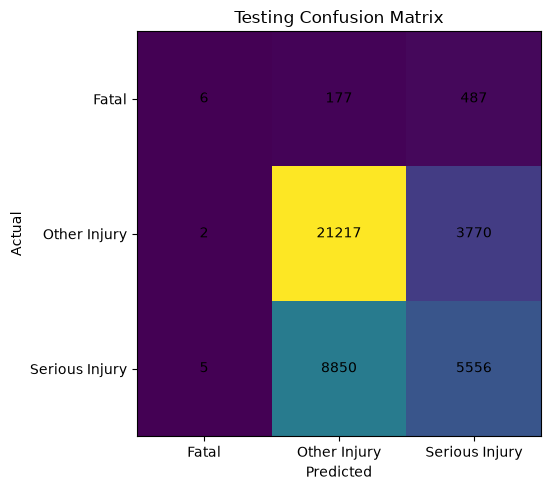

In [7]:
cm = confusion_matrix(y_test,y_pred)
print(cm)
plt.figure(figsize=(6,5)); plt.imshow(cm); plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Testing Confusion Matrix')
plt.xticks(range(3),['Fatal','Other Injury','Serious Injury']); plt.yticks(range(3),['Fatal','Other Injury','Serious Injury'])
for i in range(3):
    for j in range(3): plt.text(j,i,cm[i,j],ha='center',va='center')
plt.tight_layout(); plt.show()


In [8]:
print(model)
display(pd.DataFrame([test_results]))


LogisticRegression(C=0.1, max_iter=3000, penalty='l1', random_state=42,
                   solver='saga')


,Split,Accuracy,Macro Precision,Macro Recall,Macro F1,Macro ROC-AUC
0,Testing,0.668305,0.576418,0.414516,0.414854,0.765551
